## Setup

In [1]:
import pickle
import time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from utils.general_utils import PROJECT_ROOT, target_config, binomial_unc_pct
from utils.topology_utils import (Pi0Reconstructor, classify_topology, pi0_candidate,
                                  shower_dir_vec, TRUE_ORDER, TRUE_LABELS)
from utils.topology_plots import plot_topology_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print(f"device: {device}")

PION_CFG, PHOTON_CFG = target_config("pion"), target_config("photon")

EXTRACTED_DIR = PROJECT_ROOT / "extracted" / "extracted-mc"
PREPARED_DIR  = PROJECT_ROOT / "prepared" / "prepared-mc"
PRED_MC_DIR   = PROJECT_ROOT / "predictions" / "predictions-mc"
MODELS_DIR    = PROJECT_ROOT / "models"
PLOTS_DIR     = PROJECT_ROOT / "plots" / "fsi-classifier"
MODEL_DIR     = PROJECT_ROOT / "models"
for d in (PLOTS_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- load the FULL pool: every PFO, not just the hybrid classifiers' test split ---
with open(EXTRACTED_DIR / "mc_new.pkl", "rb") as f:
    tracks = pickle.load(f)
print(f"{len(tracks):,} PFOs (full pool)")

# Which of these PFOs were in the hybrid classifiers' TEST split -- needed later
# to keep FSI's own test set honest (evaluated on PFOs never used to train the
# hybrid classifiers).
with open(PREPARED_DIR / "test_tracks.pkl", "rb") as f:
    hybrid_test_tracks = pickle.load(f)
hybrid_test_pfo_ids = {t['PFO_ID'] for t in hybrid_test_tracks}
is_hybrid_test = np.array([t['PFO_ID'] in hybrid_test_pfo_ids for t in tracks])
print(f"{is_hybrid_test.sum():,} of {len(tracks):,} PFOs were in the hybrid "
      f"classifiers' test split (these will define FSI's test set)")

device: cpu
649,041 PFOs (full pool)
126,817 of 649,041 PFOs were in the hybrid classifiers' test split (these will define FSI's test set)


## run the promoted hybrid models over the full pool
This reconstructs the same summary-feature array ``data-preparation.ipynb`` builds, using ``norm_stats.pkl's`` saved mean/std so the full pool is normalised on EXACTLY the same scale the hybrid models were trained on. This is the part that has to match exactly or the scores are meaningless.

Do not proceed past this cell until the sanity check prints PASS. If it fails, the summary feature order or normalisation doesn't match what the hybrid model actually trained on, and every score downstream would be wrong.

In [2]:
with open(PREPARED_DIR / "norm_stats.pkl", "rb") as f:
    norm_stats = pickle.load(f)
SUMMARY_FEATURES = norm_stats["summary_features"]
sm_mean, sm_std = norm_stats["sm_mean"], norm_stats["sm_std"]
s_mean, s_std   = norm_stats["s_mean"], norm_stats["s_std"]

print(f"summary features (in training order): {SUMMARY_FEATURES}")

missing = [k for k in SUMMARY_FEATURES if k not in tracks[0]]
assert not missing, f"full pool is missing summary features: {missing}"

# summary array, same column order as training
summary_full = np.array(
    [[float(t[k]) for k in SUMMARY_FEATURES] for t in tracks], dtype=np.float32
)
summary_full = np.nan_to_num(summary_full, nan=0.0, posinf=0.0, neginf=0.0)
summary_full_n = ((summary_full - sm_mean) / sm_std).astype(np.float32)

# dEdX sequences, same padding/normalisation as training
MAX_SEQ = 222
seq_full = np.zeros((len(tracks), MAX_SEQ), dtype=np.float32)
mask_full = np.zeros((len(tracks), MAX_SEQ), dtype=np.float32)
for i, t in enumerate(tracks):
    L = min(t['sequence_length'], MAX_SEQ)
    seq_full[i, :L] = t['dEdX_sequence'][:L]
    mask_full[i, :L] = 1.0
seq_full_n = np.where(mask_full.astype(bool), (seq_full - s_mean[0]) / s_std[0], 0.0).astype(np.float32)


def run_hybrid_inference(model_path, n_summary):
    """Load a promoted hybrid model and score every PFO in the full pool."""
    from utils.train_classifier import HybridCNNMLP   # reuse the architecture
    model = HybridCNNMLP(n_summary=n_summary).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    probs = []
    with torch.no_grad():
        for i in range(0, len(tracks), 4096):
            seq_b  = torch.from_numpy(seq_full_n[i:i+4096]).unsqueeze(1).to(device)
            summ_b = torch.from_numpy(summary_full_n[i:i+4096, :n_summary]).to(device)
            mask_b = torch.from_numpy(mask_full[i:i+4096]).to(device)
            logits = model(seq_b, summ_b, mask_b)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)


with open(PRED_MC_DIR / f"hybrid_cnn_mlp{PION_CFG['suffix']}.pkl", "rb") as f:
    pion_res = pickle.load(f)
with open(PRED_MC_DIR / f"hybrid_cnn_mlp{PHOTON_CFG['suffix']}.pkl", "rb") as f:
    photon_res = pickle.load(f)

n_summary_used = len(SUMMARY_FEATURES)   # adjust if the promoted models used fewer

pion_probs_full   = run_hybrid_inference(MODELS_DIR / f"hybrid_cnn_mlp{PION_CFG['suffix']}.pt", n_summary_used)
photon_probs_full = run_hybrid_inference(MODELS_DIR / f"hybrid_cnn_mlp{PHOTON_CFG['suffix']}.pt", n_summary_used)

PION_T, PHOTON_T = pion_res["threshold"], photon_res["threshold"]
print(f"pion:   {pion_res['model_name']}   t={PION_T:.3f}   scored {len(pion_probs_full):,} PFOs")
print(f"photon: {photon_res['model_name']}   t={PHOTON_T:.3f}   scored {len(photon_probs_full):,} PFOs")

# --- SANITY CHECK: on the PFOs that WERE the hybrid test set, these fresh
# scores should closely match the originally saved probs. If they don't, the
# reconstruction above (feature order, normalisation) has a bug.
orig_idx = {t['PFO_ID']: i for i, t in enumerate(hybrid_test_tracks)}
full_idx_of_test = np.where(is_hybrid_test)[0]
check_ids = [tracks[i]['PFO_ID'] for i in full_idx_of_test[:2000]]
orig_probs = np.array([pion_res['probs'][orig_idx[pid]] for pid in check_ids])
new_probs  = np.array([pion_probs_full[i] for i in full_idx_of_test[:2000]])
diff = np.abs(orig_probs - new_probs)
print(f"\nsanity check (pion, 2000 PFOs from the original test set):")
print(f"  max diff: {diff.max():.6f}   mean diff: {diff.mean():.6f}")
print(f"  {'PASS' if diff.max() < 1e-4 else 'FAIL -- check feature order / normalisation'}")

summary features (in training order): ['track_chi2/ndof_proton', 'track_length', 'track_score', 'dEdX_median', 'b', 'd', 'shower_energy', 'beam_angle']
pion:   hybrid all8 -- pion target   t=0.550   scored 649,041 PFOs
photon: hybrid all8 -- photon target   t=0.570   scored 649,041 PFOs

sanity check (pion, 2000 PFOs from the original test set):
  max diff: 0.000000   mean diff: 0.000000
  PASS


## event index and truth topology over the full pool

In [3]:
rec = Pi0Reconstructor(tracks)
ev_idx, n_ev, idx_by_event = rec.ev_idx, rec.n_ev, rec.idx_by_event

def per_event(mask):
    return np.bincount(ev_idx[mask], minlength=n_ev)

true_pi_mask  = np.array([PION_CFG['is_signal'](t)   for t in tracks])
true_gam_mask = np.array([PHOTON_CFG['is_signal'](t) for t in tracks])
n_true_pi     = per_event(true_pi_mask)
n_true_gam    = per_event(true_gam_mask)
true_pi0      = rec.true_pi0.astype(int)

true_topo = np.array([classify_topology(n_true_pi[e], n_true_gam[e], true_pi0[e])
                      for e in range(n_ev)])
y = np.array([TRUE_ORDER.index(t) if t in TRUE_ORDER else -1 for t in true_topo])
keep_ev = y >= 0

# which EVENTS are entirely/partially within the hybrid test set -- an event
# counts as "test-eligible" only if ALL its PFOs were hybrid-test PFOs, so no
# training-set PFO sneaks into the FSI test set via a mixed event.
event_all_test = np.array([
    is_hybrid_test[idx_by_event[e]].all() for e in range(n_ev)
])

print(f"{keep_ev.sum():,} of {n_ev:,} events usable")
print(f"{event_all_test.sum():,} events are entirely within the hybrid test "
      f"split -- these are the only valid FSI test-set candidates")
for k, t in enumerate(TRUE_ORDER):
    print(f"  {t:<24} {int((y[keep_ev]==k).sum()):>7,}")

182,357 of 190,641 events usable
35,249 events are entirely within the hybrid test split -- these are the only valid FSI test-set candidates
  pion_production           40,453
  single_pion_production    44,374
  charge_exchange           24,979
  absorption                72,551


## event level globals built once from the full pool scores

In [4]:
def xyz(d):
    return np.array([float(d['x']), float(d['y']), float(d['z'])])

def angle_between(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return np.nan
    return float(np.degrees(np.arccos(np.clip(np.dot(u, v)/(nu*nv), -1, 1))))

E_shower = np.array([float(t['shower_energy']) for t in tracks])
E_c      = np.array([float(t.get('E_c', np.nan)) for t in tracks])
ts_arr   = np.array([float(t['track_score']) for t in tracks])

tag_gam = photon_probs_full >= PHOTON_T
chosen, gam_counts = rec.select(tag_gam, pairing="best")

GLOBAL_NAMES = ['multiplicity', 'n_showers', 'leading_shower_E',
               'leading_shower_angle_vertex', 'total_visible_E',
               'max_opening_angle', 'beam_KE', 'has_pi0', 'pi0_mass',
               'pi0_opening_angle', 'pi0_momentum']
G = {k: np.full(n_ev, np.nan) for k in GLOBAL_NAMES}

for e in range(n_ev):
    members = idx_by_event[e]
    G['multiplicity'][e] = len(members)
    G['beam_KE'][e] = float(tracks[members[0]]['beam_KE'])

    showers = [i for i in members if ts_arr[i] < 0.45 and np.isfinite(E_shower[i])]
    G['n_showers'][e] = len(showers)

    if showers:
        lead = max(showers, key=lambda i: E_shower[i])
        G['leading_shower_E'][e] = E_shower[lead]
        v_vertex = xyz(tracks[lead]['shower_start_pos']) - xyz(tracks[lead]['beam_end_pos'])
        sd = xyz(tracks[lead]['shower_direction'])
        G['leading_shower_angle_vertex'][e] = angle_between(sd, v_vertex)

        if len(showers) > 1:
            angs = [angle_between(xyz(tracks[i]['shower_direction']),
                                  xyz(tracks[j]['shower_direction']))
                    for k, i in enumerate(showers) for j in showers[k+1:]]
            angs = [a for a in angs if np.isfinite(a)]
            if angs:
                G['max_opening_angle'][e] = max(angs)

    tot = np.nansum([E_shower[i] for i in members])
    G['total_visible_E'][e] = tot if tot > 0 else np.nan

    G['has_pi0'][e] = 1.0 if e in chosen else 0.0
    if e in chosen:
        i, j = chosen[e]
        mass, phi = pi0_candidate(tracks[i], tracks[j])
        if mass is not None:
            di, dj = shower_dir_vec(tracks[i]), shower_dir_vec(tracks[j])
            p = (E_c[i]*di/np.linalg.norm(di)) + (E_c[j]*dj/np.linalg.norm(dj))
            G['pi0_mass'][e] = mass
            G['pi0_opening_angle'][e] = phi
            G['pi0_momentum'][e] = float(np.linalg.norm(p))

for k in GLOBAL_NAMES:
    v = G[k]
    print(f"  {k:<28} finite: {np.isfinite(v).sum():>7,} / {n_ev:,}")

  multiplicity                 finite: 190,641 / 190,641
  n_showers                    finite: 190,641 / 190,641
  leading_shower_E             finite: 118,718 / 190,641
  leading_shower_angle_vertex  finite: 118,718 / 190,641
  total_visible_E              finite: 190,641 / 190,641
  max_opening_angle            finite:  59,633 / 190,641
  beam_KE                      finite: 190,641 / 190,641
  has_pi0                      finite: 190,641 / 190,641
  pi0_mass                     finite:  13,655 / 190,641
  pi0_opening_angle            finite:  13,655 / 190,641
  pi0_momentum                 finite:  13,655 / 190,641


## feature sets + CONFIG + honest train/test split

In [5]:
FEATURES_FULL        = ['pi_score', 'gamma_score', 'track_score', 'track_length',
                        'dEdX_median', 'chi2_ndof', 'n_hits', 'shower_energy', 'b', 'd']
FEATURES_SCORESONLY  = FEATURES_FULL[:2]

X_pfo_full = np.column_stack([
    pion_probs_full, photon_probs_full,
    [float(t['track_score'])            for t in tracks],
    [float(t['track_length'])           for t in tracks],
    [float(t['dEdX_median'])            for t in tracks],
    [float(t['track_chi2/ndof_proton']) for t in tracks],
    [float(t['n_hits'])                 for t in tracks],
    [float(t['shower_energy'])          for t in tracks],
    [float(t['b'])                      for t in tracks],
    [float(t['d'])                      for t in tracks],
]).astype(np.float32)
X_pfo_full = np.nan_to_num(X_pfo_full, nan=0.0, posinf=0.0, neginf=0.0)

PFO_SETS = {'full': (X_pfo_full, FEATURES_FULL),
           'scoresonly': (X_pfo_full[:, :2], FEATURES_SCORESONLY)}

GLOBAL_CONT_NOPI0 = ['multiplicity', 'n_showers', 'leading_shower_E',
                     'leading_shower_angle_vertex', 'total_visible_E',
                     'max_opening_angle', 'beam_KE']
has_flags = np.column_stack([
    np.isfinite(G['leading_shower_E']).astype(np.float32),
    np.isfinite(G['max_opening_angle']).astype(np.float32),
])
raw = np.column_stack([G[k] for k in GLOBAL_CONT_NOPI0]).astype(np.float32)
raw = np.nan_to_num(raw, nan=-1.0, posinf=-1.0, neginf=-1.0)
X_glob_nopi0 = np.hstack([raw, has_flags]).astype(np.float32)
GLOBAL_SETS = {'nopi0': (X_glob_nopi0, GLOBAL_CONT_NOPI0 + ['has_shower', 'has_pair'])}

# ============================== CONFIG ==============================
PFO_SET_NAME    = 'full'
GLOBAL_SET_NAME = 'nopi0'
MODELS_TO_RUN   = ['AggregateMLP', 'DeepSets', 'InteractionNetwork']
FORCE_RETRAIN   = False
# ======================================================================

X_pfo, FEATURES = PFO_SETS[PFO_SET_NAME]
X_glob, GLOBAL_FEATURES = GLOBAL_SETS[GLOBAL_SET_NAME]
CONFIG_TAG = f"{PFO_SET_NAME}_{GLOBAL_SET_NAME}_fullpool"

# --- the split that keeps evaluation honest ---
usable = keep_ev & event_all_test
ev_test = np.where(usable)[0]

train_val_pool = np.where(keep_ev & ~event_all_test)[0]
rng = np.random.default_rng(42)
rng.shuffle(train_val_pool)
n_va = int(0.15 * len(train_val_pool))
ev_val, ev_train = train_val_pool[:n_va], train_val_pool[n_va:]

print(f"train {len(ev_train):,}   val {len(ev_val):,}   test {len(ev_test):,}")

train_pfo_idx = np.concatenate([idx_by_event[e] for e in ev_train])
mu_pfo,  sig_pfo  = X_pfo[train_pfo_idx].mean(0),  X_pfo[train_pfo_idx].std(0)
sig_pfo[sig_pfo == 0] = 1.0
X_pfo_n = ((X_pfo - mu_pfo) / sig_pfo).astype(np.float32)

mu_glob, sig_glob = X_glob[ev_train].mean(0), X_glob[ev_train].std(0)
sig_glob[sig_glob == 0] = 1.0
X_glob_n = ((X_glob - mu_glob) / sig_glob).astype(np.float32)

MAX_PFO = int(np.percentile([len(idx_by_event[e]) for e in np.where(keep_ev)[0]], 99.5))
print(f"padding to {MAX_PFO} PFOs per event")

train 126,359   val 22,298   test 33,700
padding to 9 PFOs per event


## dataset

In [6]:
class EventDataset(Dataset):
    def __init__(self, events):
        self.events = events

    def __len__(self):
        return len(self.events)

    def __getitem__(self, k):
        e = self.events[k]
        members = idx_by_event[e][:MAX_PFO]
        f = np.zeros((MAX_PFO, len(FEATURES)), dtype=np.float32)
        m = np.zeros(MAX_PFO, dtype=np.float32)
        f[:len(members)] = X_pfo_n[members]
        m[:len(members)] = 1.0
        return (torch.from_numpy(f), torch.from_numpy(m),
                torch.from_numpy(X_glob_n[e]), int(y[e]))


BATCH = 256
loaders = {k: DataLoader(EventDataset(ev), batch_size=BATCH, shuffle=(k=='train'))
           for k, ev in [('train', ev_train), ('val', ev_val), ('test', ev_test)]}
print({k: len(v) for k, v in loaders.items()}, "batches")

{'train': 494, 'val': 88, 'test': 132} batches


## models

In [7]:
class AggregateMLP(nn.Module):
    def __init__(self, n_feat, n_glob, n_class=4, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat*2 + n_glob, 96), nn.BatchNorm1d(96), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(96, 48), nn.BatchNorm1d(48), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(48, n_class),
        )

    def forward(self, x, mask, g):
        m = mask.unsqueeze(-1)
        n = m.sum(dim=1).clamp(min=1)
        mean = (x * m).sum(dim=1) / n
        mx = x.masked_fill(m == 0, -1e9).max(dim=1).values
        return self.net(torch.cat([mean, mx, g], dim=1))


class DeepSets(nn.Module):
    def __init__(self, n_feat, n_glob, n_class=4, h=64, dropout=0.3):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(n_feat, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
        )
        self.rho = nn.Sequential(
            nn.Linear(2*h + 1 + n_glob, 96), nn.BatchNorm1d(96), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(96, 48), nn.BatchNorm1d(48), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(48, n_class),
        )

    def forward(self, x, mask, g):
        m = mask.unsqueeze(-1)
        h = self.phi(x) * m
        n = m.sum(dim=1).clamp(min=1)
        pooled = torch.cat([h.sum(dim=1)/n, h.masked_fill(m==0, -1e9).max(dim=1).values, n, g], dim=1)
        return self.rho(pooled)


class InteractionNetwork(nn.Module):
    """One round of message passing on a fully connected graph over the PFOs
    in an event."""
    def __init__(self, n_feat, n_glob, n_class=4, h=64, edge_dim=64, dropout=0.3):
        super().__init__()
        self.f_R = nn.Sequential(
            nn.Linear(2*n_feat, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, edge_dim),
        )
        self.f_O = nn.Sequential(
            nn.Linear(n_feat + edge_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
        )
        self.rho = nn.Sequential(
            nn.Linear(2*h + 1 + n_glob, 96), nn.BatchNorm1d(96), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(96, 48), nn.BatchNorm1d(48), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(48, n_class),
        )

    def forward(self, x, mask, g):
        B, N, Fdim = x.shape
        xi = x.unsqueeze(2).expand(B, N, N, Fdim)
        xj = x.unsqueeze(1).expand(B, N, N, Fdim)
        edge_eff = self.f_R(torch.cat([xi, xj], dim=-1))

        mi, mj = mask.unsqueeze(2), mask.unsqueeze(1)
        eye = torch.eye(N, device=x.device).bool().unsqueeze(0)
        edge_mask = (mi * mj) * (~eye).float()
        edge_eff = edge_eff * edge_mask.unsqueeze(-1)

        n_senders = edge_mask.sum(dim=2, keepdim=True).clamp(min=1)
        agg = edge_eff.sum(dim=2) / n_senders

        node_out = self.f_O(torch.cat([x, agg], dim=-1)) * mask.unsqueeze(-1)
        n = mask.sum(dim=1, keepdim=True).clamp(min=1)
        pooled = torch.cat([node_out.sum(dim=1)/n,
                           node_out.masked_fill(mask.unsqueeze(-1)==0,-1e9).max(dim=1).values,
                           n, g], dim=1)
        return self.rho(pooled)


MODEL_BUILDERS = {'AggregateMLP': AggregateMLP, 'DeepSets': DeepSets,
                  'InteractionNetwork': InteractionNetwork}

for name, M in MODEL_BUILDERS.items():
    n = sum(p.numel() for p in M(len(FEATURES), X_glob.shape[1]).parameters())
    print(f"{name:<20} {n:,} params")

AggregateMLP         8,020 params
DeepSets             27,508 params
InteractionNetwork   37,108 params


## training utilities and save/load helpers

In [8]:
def result_paths(model_name):
    tag = f"{model_name}_{CONFIG_TAG}"
    return {
        'model':   MODEL_DIR / f"fsi_{tag}.pt",
        'results': PRED_MC_DIR / f"fsi_results_{tag}.pkl",
    }


def save_result(model_name, model, preds, ys, acc, hist):
    paths = result_paths(model_name)
    torch.save(model.state_dict(), paths['model'])
    with open(paths['results'], 'wb') as f:
        pickle.dump({'preds': preds, 'ys': ys, 'acc': acc, 'history': hist,
                    'features': FEATURES, 'globals': GLOBAL_FEATURES,
                    'config_tag': CONFIG_TAG}, f)
    print(f"  saved {paths['results'].name}")


def load_result(model_name):
    paths = result_paths(model_name)
    if not paths['results'].exists() or not paths['model'].exists():
        return None
    with open(paths['results'], 'rb') as f:
        saved = pickle.load(f)
    model = MODEL_BUILDERS[model_name](len(FEATURES), X_glob.shape[1])
    model.load_state_dict(torch.load(paths['model'], map_location='cpu'))
    return model, saved['preds'], saved['ys'], saved['acc'], saved['history']


def run_epoch(model, loader, crit, opt=None):
    train = opt is not None
    model.train() if train else model.eval()
    tot, n, correct = 0.0, 0, 0
    preds_all, ys_all = [], []
    with torch.set_grad_enabled(train):
        for f, m, g, t in loader:
            f, m, g, t = f.to(device), m.to(device), g.to(device), t.to(device)
            out = model(f, m, g)
            loss = crit(out, t)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()*len(t); n += len(t)
            p = out.argmax(1)
            correct += (p == t).sum().item()
            preds_all.append(p.cpu().numpy()); ys_all.append(t.cpu().numpy())
    return tot/n, correct/n, np.concatenate(preds_all), np.concatenate(ys_all)


class MulticlassFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma, self.weight = gamma, weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def train_model(model, label, epochs=60, patience=10):
    model = model.to(device)
    crit = MulticlassFocalLoss(gamma=2.0, weight=None)   # best config found
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=4)

    best, wait, best_state = float('inf'), 0, None
    hist = {'train': [], 'val': [], 'val_acc': []}
    t0 = time.perf_counter()
    print(f"\n=== training {label} ({CONFIG_TAG}) ===")
    for ep in range(epochs):
        tr, _, _, _ = run_epoch(model, loaders['train'], crit, opt)
        va, va_acc, _, _ = run_epoch(model, loaders['val'], crit)
        sched.step(va)
        hist['train'].append(tr); hist['val'].append(va); hist['val_acc'].append(va_acc)
        if (ep+1) % 10 == 0 or ep == 0:
            print(f"  epoch {ep+1:3d}  train {tr:.4f}  val {va:.4f}  acc {100*va_acc:.1f}%")
        if va < best:
            best, wait, best_state = va, 0, {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  early stop at epoch {ep+1}"); break
    model.load_state_dict(best_state)
    print(f"  {time.perf_counter()-t0:.0f}s")
    return model, hist


def get_or_train(model_name):
    if not FORCE_RETRAIN:
        loaded = load_result(model_name)
        if loaded is not None:
            model, preds, ys, acc, hist = loaded
            print(f"{model_name} ({CONFIG_TAG}): loaded saved result, "
                  f"accuracy {100*acc:.1f}% -- skipping training")
            return model.to(device), preds, ys, acc

    model, hist = train_model(MODEL_BUILDERS[model_name](len(FEATURES), X_glob.shape[1]), model_name)
    crit = nn.CrossEntropyLoss()
    _, acc, preds, ys = run_epoch(model, loaders['test'], crit)
    save_result(model_name, model, preds, ys, acc, hist)
    return model, preds, ys, acc

## Run whichever models are configured

In [9]:
trained = {}
for name in MODELS_TO_RUN:
    trained[name] = get_or_train(name)

agg_model = trained.get('AggregateMLP', (None,))[0]
ds_model  = trained.get('DeepSets', (None,))[0]
in_model  = trained.get('InteractionNetwork', (None,))[0]

AggregateMLP (full_nopi0_fullpool): loaded saved result, accuracy 65.8% -- skipping training
DeepSets (full_nopi0_fullpool): loaded saved result, accuracy 67.8% -- skipping training
InteractionNetwork (full_nopi0_fullpool): loaded saved result, accuracy 67.6% -- skipping training


## Save the results for analysis

In [10]:
tag_pi_test  = per_event(pion_probs_full >= PION_T)[ev_test]
tag_gam_test = per_event(photon_probs_full >= PHOTON_T)[ev_test]
tag_pi0_test = rec.pi0_flags(photon_probs_full >= PHOTON_T, pairing="best")[ev_test]

test_artifacts = {
    'config_tag':        CONFIG_TAG,
    'y_test':            y[ev_test],
    'true_topo_test':    true_topo[ev_test],
    'n_true_pi_test':    n_true_pi[ev_test],
    'multiplicity_test': G['multiplicity'][ev_test],
    'tag_pi_test':       tag_pi_test,
    'tag_gam_test':      tag_gam_test,
    'tag_pi0_test':      tag_pi0_test,
    'has_pi0_test':      G['has_pi0'][ev_test],
    'n_gam_tagged_test': tag_gam_test,
    'pion_threshold':    PION_T,
    'photon_threshold':  PHOTON_T,
}

artifacts_path = PRED_MC_DIR / f"fsi_test_artifacts_{CONFIG_TAG}.pkl"
with open(artifacts_path, "wb") as f:
    pickle.dump(test_artifacts, f)
print(f"saved {artifacts_path}  ({len(ev_test):,} test events)")

saved /home/pemb7173/PDSP-pion-classification/predictions/predictions-mc/fsi_test_artifacts_full_nopi0_fullpool.pkl  (33,700 test events)


## confidence scores

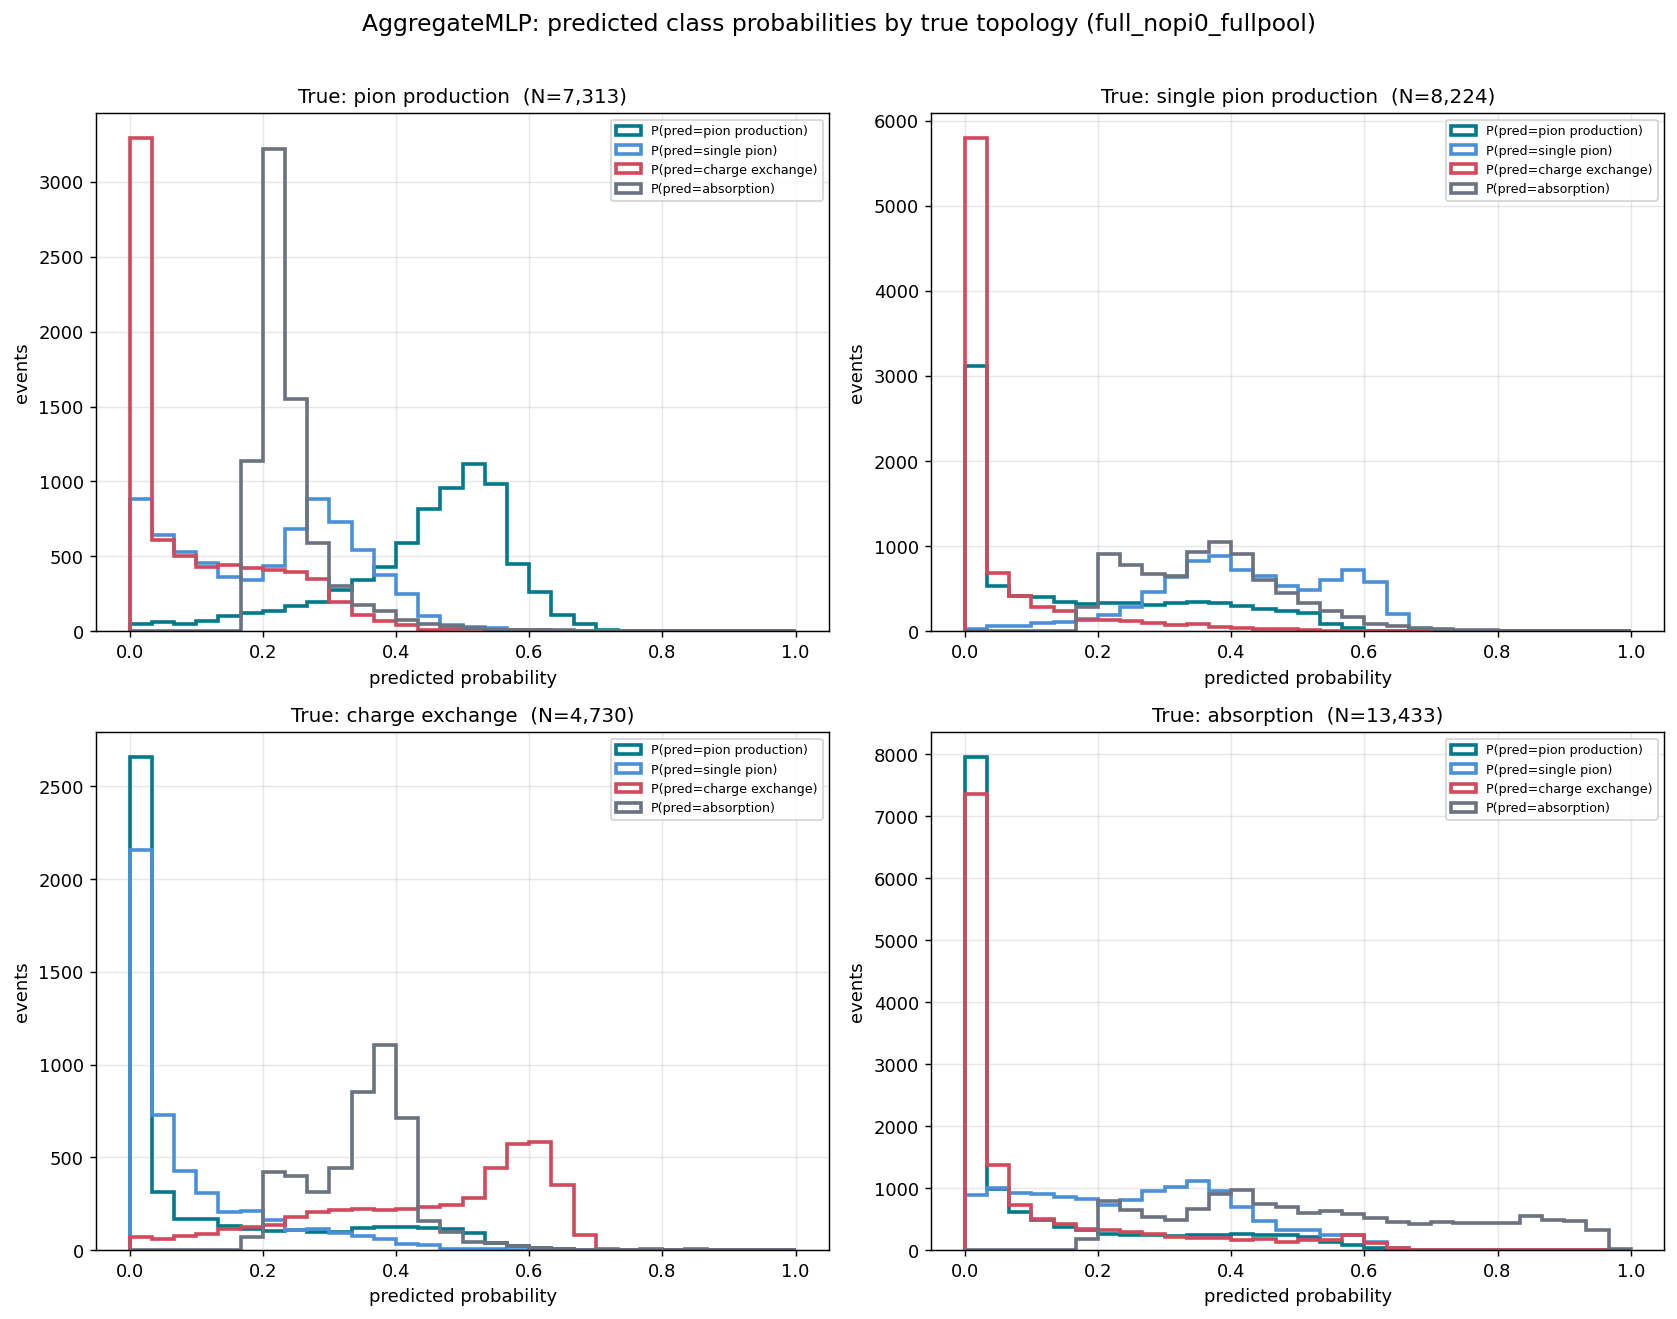

saved /home/pemb7173/PDSP-pion-classification/plots/fsi-classifier/confidence_by_topology_AggregateMLP_full_nopi0_fullpool.pdf


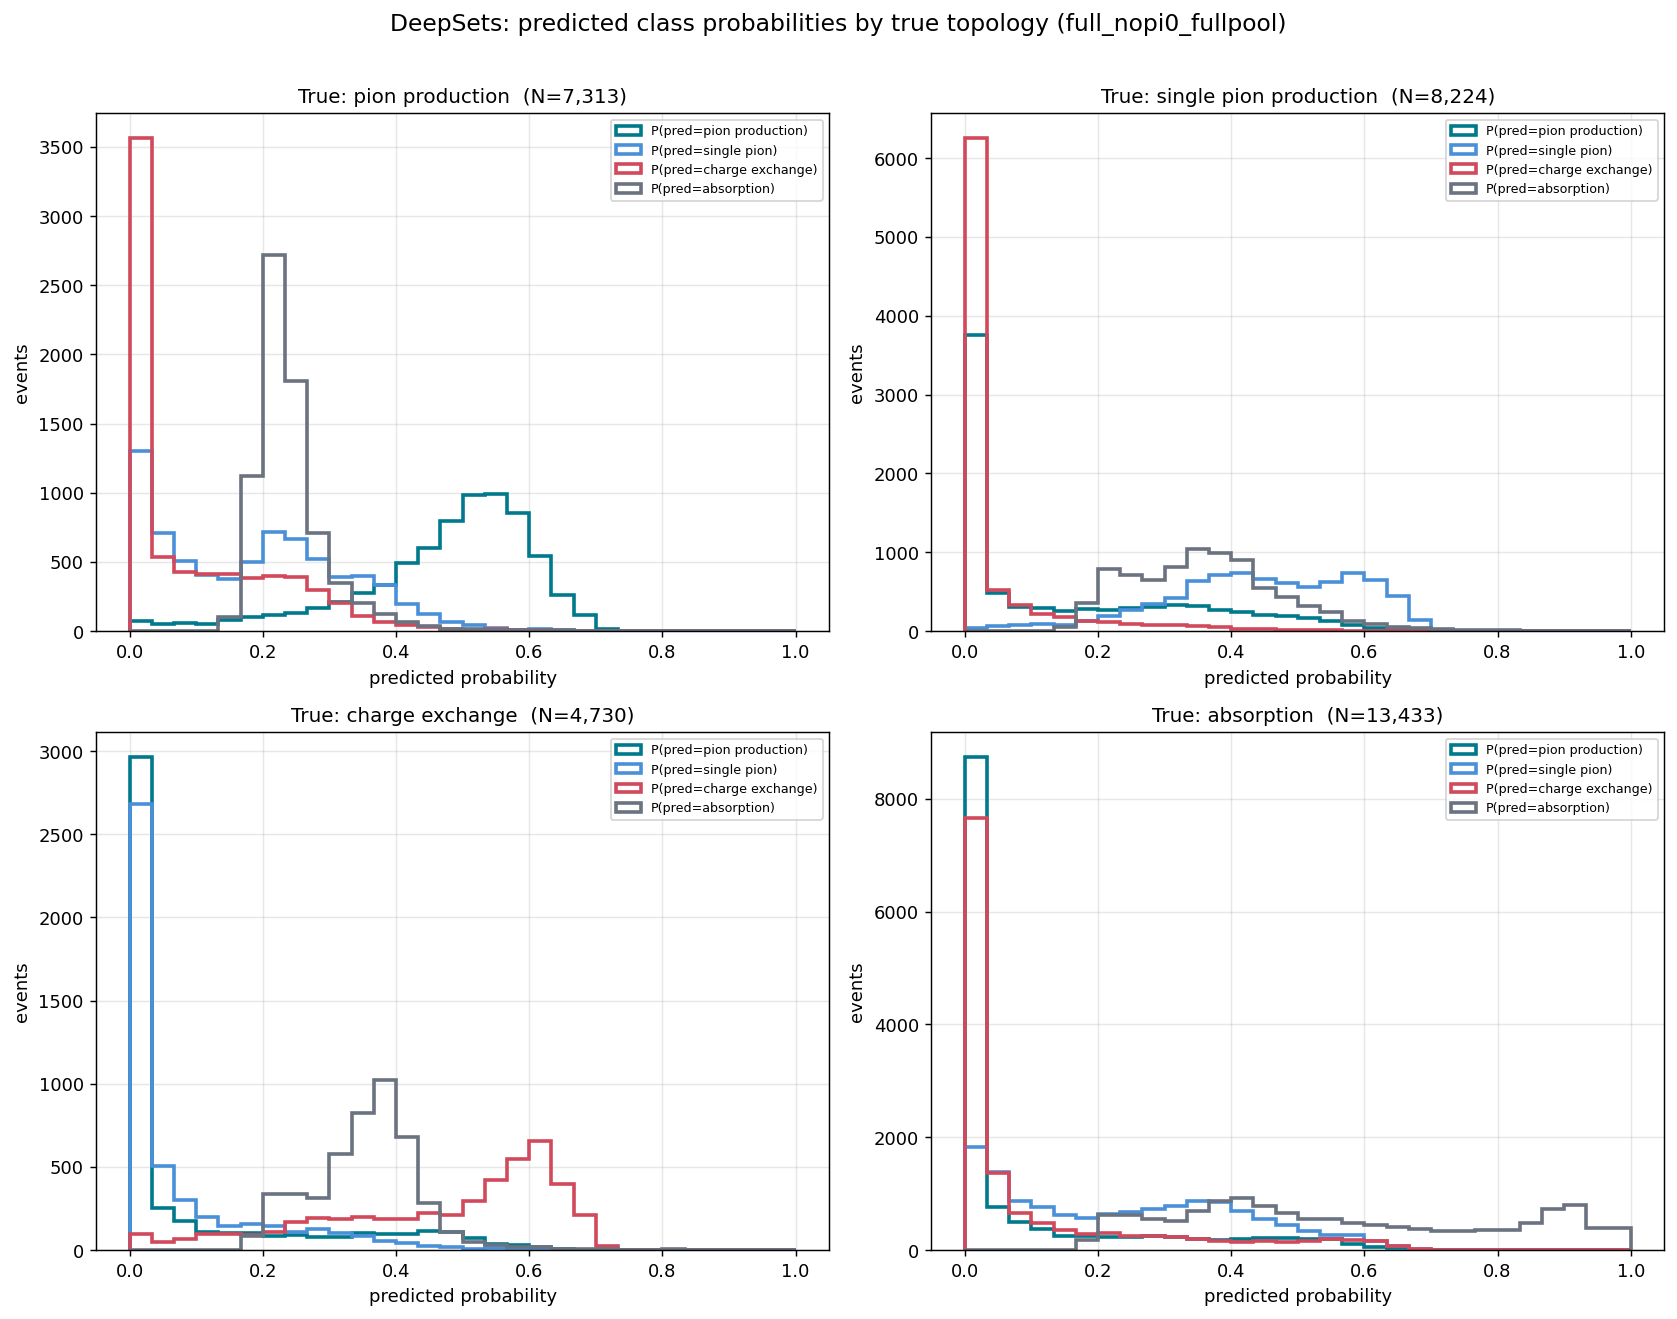

saved /home/pemb7173/PDSP-pion-classification/plots/fsi-classifier/confidence_by_topology_DeepSets_full_nopi0_fullpool.pdf


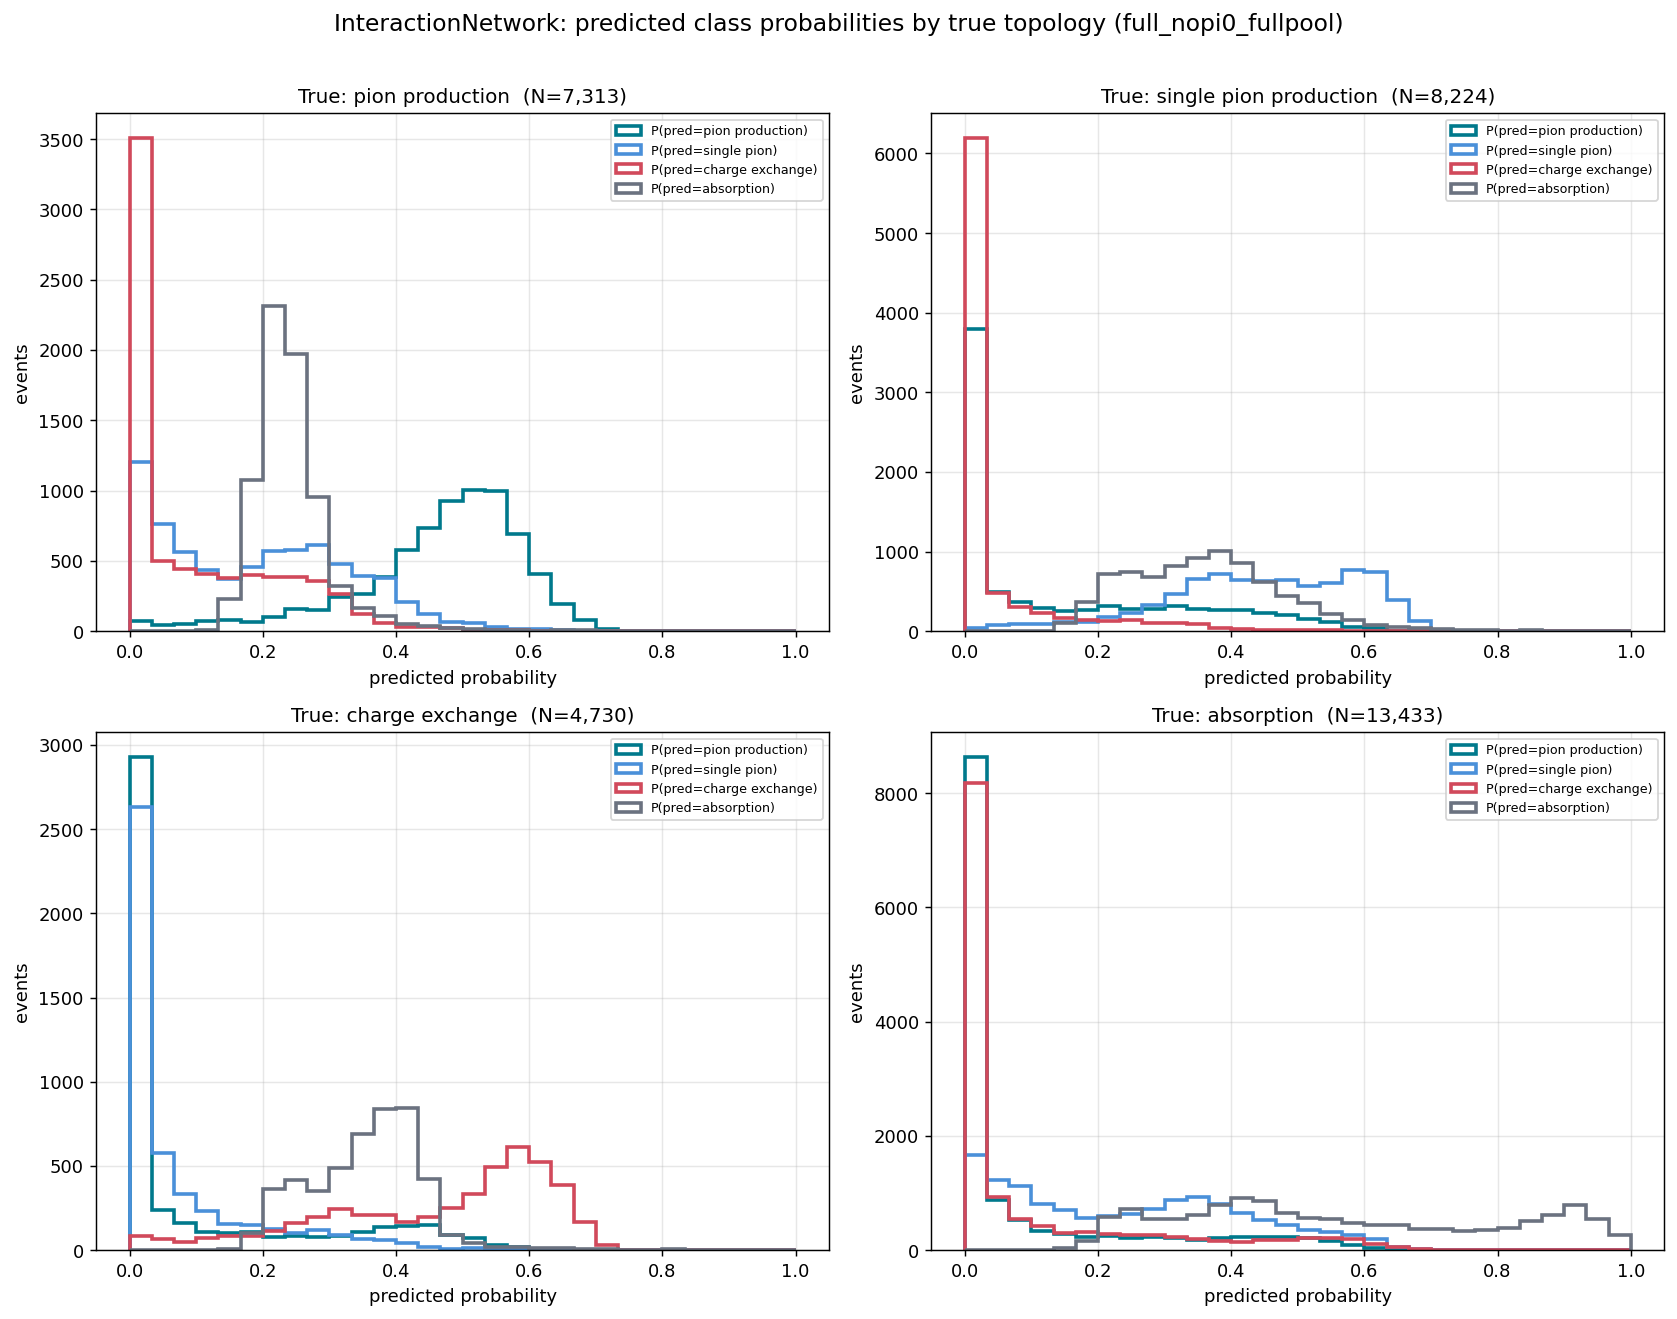

saved /home/pemb7173/PDSP-pion-classification/plots/fsi-classifier/confidence_by_topology_InteractionNetwork_full_nopi0_fullpool.pdf


In [11]:
def get_softmax(model, loader):
    model.eval()
    probs_all, ys_all = [], []
    with torch.no_grad():
        for f, m, g, t in loader:
            f, m, g = f.to(device), m.to(device), g.to(device)
            probs_all.append(torch.softmax(model(f, m, g), dim=1).cpu().numpy())
            ys_all.append(t.numpy())
    if not probs_all:
        return np.empty((0, 4)), np.empty((0,), dtype=int)
    return np.concatenate(probs_all), np.concatenate(ys_all)


CLASS_COLORS = {'pion_production': '#00798c', 'single_pion_production': '#4a90d9',
                'charge_exchange': '#d1495b', 'absorption': '#6b7280'}
bins = np.linspace(0, 1, 31)

if not trained:
    print("nothing trained this session -- nothing to plot")
elif len(loaders.get('test', [])) == 0:
    print("test loader is empty -- nothing to plot")
else:
    for model_name, (model, preds, ys, acc) in trained.items():
        if model is None:
            print(f"{model_name}: not trained/loaded -- skipping")
            continue

        softmax_probs, ys_test = get_softmax(model, loaders['test'])
        if len(ys_test) == 0:
            print(f"{model_name}: no test predictions returned -- skipping")
            continue

        fig, ax = plt.subplots(2, 2, figsize=(13, 10), dpi=130)
        ax = ax.ravel()
        any_panel_drawn = False

        for i, (true_t, true_lab) in enumerate(zip(TRUE_ORDER, TRUE_LABELS)):
            mask = ys_test == i
            n_events = int(mask.sum())

            if n_events == 0:
                ax[i].text(0.5, 0.5, "no test events\nfor this topology",
                          ha='center', va='center', transform=ax[i].transAxes,
                          fontsize=11, color='grey')
                ax[i].set_title(f"True: {true_lab.replace(chr(10),' ')}  (N=0)", fontsize=11)
                ax[i].set_xlim(0, 1); ax[i].set_ylim(0, 1)
                continue

            any_panel_drawn = True
            for j, (pred_t, pred_lab) in enumerate(zip(TRUE_ORDER, TRUE_LABELS)):
                vals = softmax_probs[mask, j]
                if len(vals) == 0:
                    continue
                ax[i].hist(vals, bins=bins, histtype='step', lw=2,
                          color=CLASS_COLORS[pred_t],
                          label=f"P(pred={pred_lab.splitlines()[0]})")
            ax[i].set_title(f"True: {true_lab.replace(chr(10),' ')}  (N={n_events:,})", fontsize=11)
            ax[i].set_xlabel('predicted probability')
            ax[i].set_ylabel('events')
            ax[i].legend(fontsize=7)
            ax[i].grid(alpha=0.3)

        if not any_panel_drawn:
            print(f"{model_name}: every topology had zero test events -- "
                  f"skipping save, closing figure")
            plt.close(fig)
            continue

        fig.suptitle(f'{model_name}: predicted class probabilities by true topology '
                     f'({CONFIG_TAG})', fontsize=13, y=1.01)
        plt.tight_layout()
        out_path = PLOTS_DIR / f"confidence_by_topology_{model_name}_{CONFIG_TAG}.pdf"
        plt.savefig(out_path, bbox_inches='tight')
        plt.show()
        print(f"saved {out_path}")